# 과제 7 — CNN 이미지 분류

## CIFAR-10 데이터셋 로드

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

num_classes = 10

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64)

classes = ('airplane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'학습: {len(train_dataset)}장, 테스트: {len(test_dataset)}장')


학습: 50000장, 테스트: 10000장


## CNN 모델 구성

In [2]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN(num_classes)
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 학습 및 평가

In [3]:
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
n_batches = len(train_loader)

for epoch in range(10):
    model.train()
    train_loss, train_correct = 0, 0

    for i, (X_b, y_b) in enumerate(train_loader):
        optimizer.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * len(y_b)
        train_correct += (out.argmax(1) == y_b).sum().item()

        if (i + 1) % 100 == 0 or (i + 1) == n_batches:
            print(f'  Epoch {epoch+1}/10  [{i+1}/{n_batches}]  batch_loss: {loss.item():.4f}', end='\r')

    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader:
            out         = model(X_b)
            val_loss    += criterion(out, y_b).item() * len(y_b)
            val_correct += (out.argmax(1) == y_b).sum().item()

    n_tr, n_te = len(train_dataset), len(test_dataset)
    history['loss'].append(train_loss / n_tr)
    history['accuracy'].append(train_correct / n_tr)
    history['val_loss'].append(val_loss / n_te)
    history['val_accuracy'].append(val_correct / n_te)

    print(f'Epoch {epoch+1:2d}/10  '
          f'loss: {history["loss"][-1]:.4f}  acc: {history["accuracy"][-1]:.4f}  '
          f'val_loss: {history["val_loss"][-1]:.4f}  val_acc: {history["val_accuracy"][-1]:.4f}')


Epoch  1/10  loss: 1.3182  acc: 0.5221  val_loss: 1.0244  val_acc: 0.6354
Epoch  2/10  loss: 0.8842  acc: 0.6890  val_loss: 0.8026  val_acc: 0.7200
Epoch  3/10  loss: 0.7089  acc: 0.7519  val_loss: 0.7443  val_acc: 0.7461
Epoch  4/10  loss: 0.5790  acc: 0.7964  val_loss: 0.7610  val_acc: 0.7423
Epoch  5/10  loss: 0.4702  acc: 0.8346  val_loss: 0.7446  val_acc: 0.7583
Epoch  6/10  loss: 0.3754  acc: 0.8673  val_loss: 0.7735  val_acc: 0.7608
Epoch  7/10  loss: 0.2952  acc: 0.8964  val_loss: 0.8008  val_acc: 0.7607
Epoch  8/10  loss: 0.2303  acc: 0.9181  val_loss: 0.9394  val_acc: 0.7573
Epoch  9/10  loss: 0.1771  acc: 0.9373  val_loss: 0.9780  val_acc: 0.7599
Epoch 10/10  loss: 0.1455  acc: 0.9488  val_loss: 1.0920  val_acc: 0.7580


테스트 정확도: 0.7580


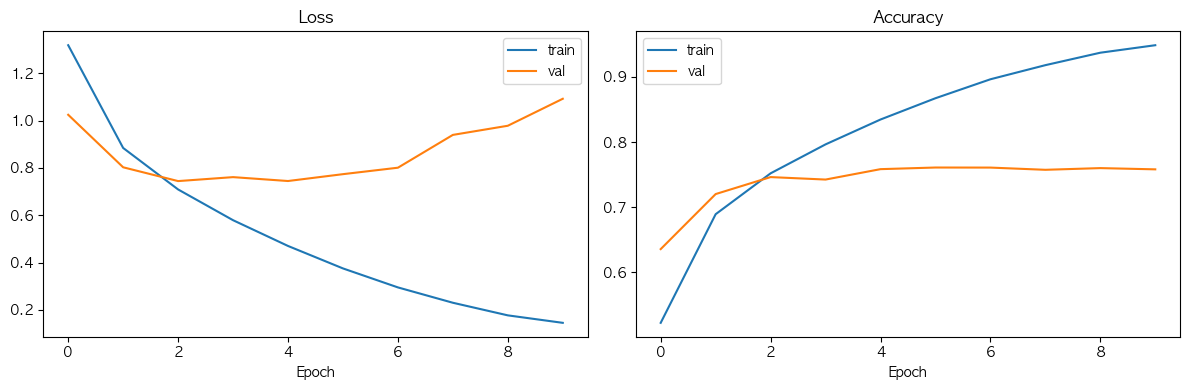

In [4]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print(f'테스트 정확도: {history["val_accuracy"][-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['accuracy'], label='train')
axes[1].plot(history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


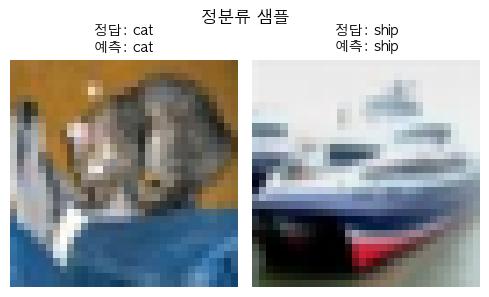

In [5]:
# 정분류 샘플 이미지 시각화
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

images, labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
    preds = model(images).argmax(1)

correct_idx = (preds == labels).nonzero(as_tuple=True)[0][:2]

fig, axes = plt.subplots(1, 2, figsize=(5, 3))
for ax, idx in zip(axes, correct_idx):
    img = (images[idx] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f'정답: {classes[labels[idx]]}\n예측: {classes[preds[idx]]}', fontsize=10)
    ax.axis('off')

plt.suptitle('정분류 샘플', fontsize=12)
plt.tight_layout()
plt.show()
